# Sanskrit Varna Sanyoga Analysis


This notebook analyzes वर्ण-संयोग (varna-sanyoga or character combinations) in Sanskrit texts, specifically focusing on
- anusvara (ं) followed by consonants and
- म् ्  followed by vowels.

## The Anusvara and Consonant Combinations (ं + व्यञ्जनानि)

It organizes the Sanskrit consonants (व्यञ्जनानि) into their traditional वर्ग (varga) groups.
It has the ability to count and group anusvara followed by consonants into their respective वर्ग (varga) categories.

This count is accomplised using the `zoekt` search engine, which is efficient for searching large text corpora. The Sanchaya corpus indexed with `zoekt` is used for this analysis.

1. कवर्ग (Kavarga): क् ख् ग् घ् ङ्  
2. चवर्ग (Cavarga): च् छ् ज् झ् ञ्  
3. टवर्ग (Ṭavarga): ट् ठ् ड् ढ् ण्  
4. तवर्ग (Tavarga): त् थ् द् ध् न्  
5. पवर्ग (Pavarga): प् फ् ब् भ् म्  
6. यवर्ग (Ya): य्  
7. रवर्ग (Ra): र्  
8. लवर्ग (La): ल्  
9. ववर्ग (Va): व्  
10. शवर्ग (Śa): श्  
11. षवर्ग (Ṣa): ष्  
12. सवर्ग (Sa): स्  
13. हवर्ग (Ha): ह्  

## The म् ् and Vowel Combinations (म् + स्वरः)

The analysis also counts occurrences of म् ् (m followed by a halanta) followed by each of the vowels in Sanskrit. The vowels are 
1. अ (a)
2. आ (ā)
3. इ (i)
4. ई (ī)
5. उ (u)
6. ऊ (ū)
7. ऋ (ṛ)
8. ॠ (ṝ)
9. ऌ (ḷ)
10. ॡ (ḹ)
11. ए (e)
12. ऐ (ai)
13. ओ (o)
14. औ (au)


To perform this analysis, sandhi viccheda of text next is needed that sanchaya does not have. The 00_llm_pre_process notebook genrates the necessary text  files is `./llm_pre_processed/{file}_llm_pp.md`  whose format is shown below:

```markdown
## Verse 1.1

### Original Sloka
१.१ ॰प्रणिपत्य एकमनेकं कं सत्यां देवतां परं ब्रह्म्
१.१ आर्यभटस्त्रीणि ॰गदति गणितं कालक्रियां गोलम्

### Padacheda:
प्रणिपत्य एकमनेकम् कम् सत्यम् देवताम् परम् ब्रह्म् आर्यभटस्त्रीणि गदति गणितम् कालक्रियम् गोलम् ।

### Patterns म् + स्वर:  
|verse|म्+स्वरः|instances | count |
|---|---|---|---|
|1.1|आ|ब्रह्म् आर्यभटस्त्रीणि | 1|

```
The `Patterns म् + स्वर:` section lists the occurrences of म् ् followed by each vowel, along with the verse and instances. This is aggregated across all the verses for a given work.


## Output Files

Between the anusvara+ and msvara analyses, this notebook generates a comprehensive overview of the character combinations in these files

### msound_raw.csv
For each work for, it has the count of occurrences of each anusvara(ं+व्यञ्जनानि) and msvara (म्+स्वरः) combination.

### msound_normalized.csv 
This file contains the same information as msound_raw.csv but in a normalized format, making it easier to analyze and visualize the data.

These files are used for visualization and further analysis by other notebook/scripts


In [1]:
# Import required libraries
import subprocess
import re
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

## Define Sanskrit Character Groups (Varna Varga)

Here we define the traditional Sanskrit character groups (vargas) and map each consonant to its respective varga. These groups are organized according to the place of articulation in the Sanskrit phonological system.

In [2]:
# Define the character groups
char_groups = {
    ('Kavarga', 'ka') : ['क्'], ('Kavarga', 'kha') : ['ख्'], ('Kavarga', 'ga') : ['ग्'], ('Kavarga', 'gha') : ['घ्'], ('Kavarga', 'nga') : ['ङ्'],
    ('Cavarga', 'cha') : ['च्'], ('Cavarga', 'chha') : ['छ्'], ('Cavarga', 'ja') : ['ज्'], ('Cavarga', 'jha') : ['झ्'], ('Cavarga', 'nya') : ['ञ्'],
    ('Ṭavarga', 'ṭa') : ['ट्'], ('Ṭavarga', 'ṭha') : ['ठ्'], ('Ṭavarga', 'ḍa') : ['ड्'], ('Ṭavarga', 'ḍha') : ['ढ्'], ('Ṭavarga', 'ṇa') : ['ण्'],
    ('Tavarga', 'ta') : ['त्'], ('Tavarga', 'tha') : ['थ्'], ('Tavarga', 'da') : ['द्'], ('Tavarga', 'dha') : ['ध्'], ('Tavarga', 'na') : ['न्'],
    ('Pavarga', 'pa') : ['प्'], ('Pavarga', 'pha') : ['फ्'], ('Pavarga', 'ba') : ['ब्'], ('Pavarga', 'bha') : ['भ्'], ('Pavarga', 'ma') : ['म्'],

    ('Yogavaṅśa', 'ya') : ['य्'], ('Yogavaṅśa', 'ra') : ['र्'], ('Yogavaṅśa', 'la') : ['ल्'], ('Yogavaṅśa', 'va') : ['व्'],
    ('Sibilant', 'śa') : ['श्'], ('Sibilant', 'ṣa') : ['ष्'], ('Sibilant', 'sa') : ['स्'],
    ('Visarga', 'ha'): ['ह्'], 
    # ('Anusvāra', 'aṃ'): ['ं'], ('Anusvāra', 'aḥ'): ['ः'], 
    # ('Vowel', 'a'): ['अ'],('Vowel', 'ā'): ['आ'],
    # ('Vowel', 'i'): ['इ'], ('Vowel', 'ī'): ['ई'], 
    # ('Vowel', 'u'): ['उ'], ('Vowel', 'ū'): ['ऊ'],
    # ('Vowel', 'e'): ['ए'], ('Vowel', 'ai'): ['ऐ'],
    # ('Vowel', 'o'): ['ओ'], ('Vowel', 'au'): ['औ']
}

# Define the varga groups
varga_groups = {
    'कवर्ग (Kavarga)': ['क्', 'ख्', 'ग्', 'घ्', 'ङ्'],
    'चवर्ग (Cavarga)': ['च्', 'छ्', 'ज्', 'झ्', 'ञ्'],
    'टवर्ग (Ṭavarga)': ['ट्', 'ठ्', 'ड्', 'ढ्', 'ण्'],
    'तवर्ग (Tavarga)': ['त्', 'थ्', 'द्', 'ध्', 'न्'],
    'पवर्ग (Pavarga)': ['प्', 'फ्', 'ब्', 'भ्', 'म्'],
    'य (Ya)': ['य्'],
    'र (Ra)': ['र्'],
    'ल (La)': ['ल्'],
    'व (Va)': ['व्'],
    'श (Śa)': ['श्'],
    'ष (Ṣa)': ['ष्'],
    'स (Sa)': ['स्'],
    'ह (Ha)': ['ह्'],
    # 'अनुस्वार (Anusvāra)': ['ं', 'ः'],
    # 'स्वर (Vowel)': ['अ', 'आ', 'इ', 'ई', 'उ', 'ऊ', 'ए', 'ऐ', 'ओ', 'औ']
}


In [3]:

# # Create a mapping from each character to its varga
# char_to_varga = {}
# for group_name, chars in varga_groups.items():
#     for char in chars:
#         char_to_varga[char] = group_name

# Create patterns for searching with zoekt
# Format: anusvara followed by a consonant with optional whitespace in between
vg_search_patterns = {}
for group_name, chars in varga_groups.items():
    # Join the characters with | for regex OR
    char_pattern = '|'.join(chars)
    # Create pattern for anusvara followed by any character from this varga
    vg_search_patterns[group_name] = f".ं\\s+[{char_pattern}]"

cg_search_patterns = {}
for group_name, chars in char_groups.items():
    # Join the characters with | for regex OR
    char_pattern = '|'.join(chars)
    # Create pattern for anusvara followed by any character from this group
    cg_search_patterns[group_name] = f".ं\\s+[{char_pattern}]"
    str_group_name = str(group_name)
    # Handle special cases for vowels and anusvāra
    if 'Vowel' in str_group_name :
        # For vowels and anusvāra, we don't need the anusvāra prefix
        pat = \
        "म" if "'a'" in str_group_name else \
        "मा" if "'ā'" in str_group_name else \
        "मि" if "'i'" in str_group_name else \
        "मी" if "'ī'" in str_group_name else \
        "मु" if "'u'" in str_group_name else \
        "मू" if "'ū'" in str_group_name else \
        "मे" if "'e'" in str_group_name else \
        "मै" if "'ai'" in str_group_name else \
        "मो" if "'o'" in str_group_name else \
        "मौ" if "'au'" in str_group_name else \
        "xमx"  # Default case, should not happen
        cg_search_patterns[group_name] = f"{pat}\S"

# # Display the search patterns
# print("Search patterns for each varga:")
# for varga, pattern in vg_search_patterns.items():
#     print(f"{varga}: {pattern}")

# print("Search patterns for each consonant group:")
# for group, pattern in cg_search_patterns.items():
#     print(f"{group}: {pattern}")

## Implement Counting with Zoekt

Zoekt is a powerful code search tool. We'll use it to search for our pattern combinations across different Sanskrit texts. The following function executes zoekt commands and parses the results.

In [4]:
# decorate the function to cache results
def cache_results(func):
    """
    Decorator to cache results of the function
    """
    cache = {}

    def wrapper(*args, **kwargs):
        key = (args, frozenset(kwargs.items()))
        if key not in cache:
            cache[key] = func(*args, **kwargs)
        return cache[key]

    return wrapper

#invalidate the cache
def invalidate_cache():
    """
    Invalidate the cache for the search_zoekt function
    """
    search_zoekt.cache.clear()  

@cache_results
def search_zoekt(pattern, file_pattern):
    """
    Search for a pattern in files matching file_pattern using zoekt
    
    Args:
        pattern: The regex pattern to search for
        file_pattern: File pattern to limit search scope
        
    Returns:
        The count of occurrences
    """

    try:
        cmd = ["zoekt", pattern, f"file:{file_pattern}"]
        result = subprocess.run(cmd, capture_output=True, text=True)
        # Count lines in the output as a proxy for occurrences
        count = len(result.stdout.strip().split('\n')) if result.stdout.strip() else 0
        # print(f"{' '.join(cmd)} executed with return {count}")
        return count
    except Exception as e:
        print(f"Error searching for pattern '{pattern}': {e}")
        return 0

def perform_cross_tabulation(file_patterns, search_patterns, use_cache=True):
    """
    Perform cross-tabulation of pattern occurrences across files
    
    Args:
        file_patterns: List of file patterns to search
        
    Returns:
        DataFrame with cross-tabulation results
    """
    if not use_cache: invalidate_cache()

    print("Collecting data...")
    
    # Initialize a DataFrame to store results
    results = pd.DataFrame(index=search_patterns.keys(), columns=file_patterns + ['Total'])
    results = results.fillna(0)
    
    # Process each file pattern
    for file_pattern in file_patterns:
        print(f"Processing {file_pattern}...")
        # Process each group pattern
        for group_name, pattern in search_patterns.items():
            count = search_zoekt(pattern, file_pattern)
            results.at[group_name, file_pattern] = count
    
    # Calculate row totals
    results['Total'] = results.sum(axis=1)
    
    # Calculate column totals
    results.loc['Total'] = results.sum()
    
    return results

## Run the Analysis

Now let's run the analysis on our Sanskrit texts. We'll use the same file patterns as in the original shell script: raghuvamsham, kumarasambhava, and meghadutam.

In [5]:
# these are the regex patterns for files from sanchaya to process
# these are carefully chosen so each pattern yields a unique file
# also if the special chars are stripeped, the name is still recognizable
file_patterns = [
    'raghuvamsham', 'kumarasambhava', 'kiratarjuniya',
    'shishupala', 'naishadiya',
    'gita.*govinda' , 'madhuravijaya',
    'meghadutam.txt', 'ratnavali', 
    'valmiki-ramayana.txt' , '^.*MB.*BORI.*$',
    "ashtanga.*hrud",
    "aryabhatiya.txt",
    "tarkasangraha",
    "udayana",
    "bharata.*natya",
    "sahrudaya",
    "gaarg",
    "shakuntalam",
    "mrcc.*dev",
    "yougandharayanam.txt",
    "bhasa.*svapna",
    "mudra.*raks",
    # anargha by murari
]

In [6]:



# results_cg = perform_cross_tabulation(file_patterns, cg_search_patterns

ANUSVARA={}
for patterns, group_name in zip([vg_search_patterns, cg_search_patterns], ['Grouped Consonants', 'Individual Consonant']):
    print(f"\nCross-tabulation for {group_name} patterns:")
    # Perform cross-tabulation for varga patterns
    print("-" * 40)
    results = perform_cross_tabulation(file_patterns, patterns, use_cache=True)
    results.columns = [col.replace('.txt', '') for col in results.columns]
    # clean up columns names - remove special characters and edge spaces
    results.columns = [re.sub(r'[^a-zA-Z0-9_\S]', '', col).strip() for col in results.columns]
    results.columns = [re.sub(r'^\W*', '', col).strip() for col in results.columns]
    results.columns = [re.sub(r'\W*$', '', col).strip() for col in results.columns]
    results.columns = [re.sub(r'\W\W*', '_', col).strip() for col in results.columns]

    # normalize each cell by the sum of its column except for the 'Total' row
    results_normalized = results.copy().drop('Total', axis=0)
    for col in results_normalized.columns: 
        results_normalized[col] = results_normalized[col] / results_normalized[col].sum()


    ANUSVARA[group_name] = { 
        'raw': results,
        'normalized': results_normalized
    }

    # Display the results
    display(
        HTML(f"<h2>Anusvara+ Occurrences by {group_name}</h2>"),
        results_normalized.style.format("{:.1%}").background_gradient(cmap='coolwarm').set_caption(f"Normalized Counts of Anusvara+ Occurrences by {group_name}"),
        HTML("<hr>"),
        HTML(f"<h2>Raw Counts of Anusvara+ Occurrences by {group_name}</h2>"),
        results.style.background_gradient(cmap='Reds').format("{:,}"),
        HTML("<hr>"))



Cross-tabulation for Grouped Consonants patterns:
----------------------------------------
Processing raghuvamsham...
Processing kumarasambhava...
Processing kiratarjuniya...
Processing shishupala...
Processing naishadiya...
Processing gita.*govinda...
Processing madhuravijaya...
Processing meghadutam.txt...
Processing ratnavali...
Processing valmiki-ramayana.txt...
Processing ^.*MB.*BORI.*$...
Processing ashtanga.*hrud...
Processing aryabhatiya.txt...
Processing tarkasangraha...
Processing udayana...
Processing bharata.*natya...
Processing sahrudaya...
Processing gaarg...
Processing shakuntalam...
Processing mrcc.*dev...
Processing yougandharayanam.txt...
Processing bhasa.*svapna...
Processing mudra.*raks...


,raghuvamsham,kumarasambhava,kiratarjuniya,shishupala,naishadiya,gita_govinda,madhuravijaya,meghadutam,ratnavali,valmiki_ramayana,MB_BORI,ashtanga_hrud,aryabhatiya,tarkasangraha,udayana,bharata_natya,sahrudaya,gaarg,shakuntalam,mrcc_dev,yougandharayanam,bhasa_svapna,mudra_raks,Total
कवर्ग (Kavarga),9.2%,11.4%,10.1%,12.4%,11.7%,17.1%,13.5%,10.6%,13.6%,9.6%,9.8%,11.6%,14.8%,9.9%,13.1%,10.8%,10.4%,10.6%,12.4%,14.9%,18.4%,16.0%,12.9%,10.3%
चवर्ग (Cavarga),6.9%,7.0%,6.3%,8.7%,5.6%,9.1%,6.0%,6.7%,10.1%,9.2%,10.6%,11.6%,8.9%,12.8%,11.3%,13.9%,9.9%,14.9%,5.6%,8.5%,3.9%,5.8%,6.8%,10.3%
टवर्ग (Ṭavarga),0.0%,0.0%,0.0%,0.1%,0.0%,0.0%,0.0%,0.0%,4.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.2%,0.1%,0.0%,3.2%,2.7%,4.3%,0.3%,0.1%
तवर्ग (Tavarga),20.6%,21.7%,24.4%,19.0%,26.7%,18.7%,22.6%,24.6%,22.4%,21.1%,21.4%,18.0%,16.6%,21.5%,20.7%,23.3%,19.9%,19.0%,23.8%,21.1%,19.5%,18.0%,20.5%,21.1%
पवर्ग (Pavarga),24.5%,24.5%,24.4%,19.2%,21.3%,20.3%,22.2%,22.5%,25.7%,22.3%,23.8%,20.7%,20.1%,20.3%,15.3%,20.4%,19.5%,19.4%,26.3%,25.8%,26.7%,29.5%,22.6%,22.9%
य (Ya),3.7%,3.6%,2.6%,6.3%,4.4%,3.3%,2.5%,6.7%,1.3%,3.0%,4.3%,3.1%,5.3%,2.3%,3.2%,3.4%,5.8%,4.4%,2.7%,1.3%,2.4%,0.6%,4.1%,4.0%
र (Ra),4.4%,1.8%,2.4%,3.6%,2.2%,5.6%,3.7%,3.0%,1.7%,5.7%,2.9%,2.7%,1.8%,2.3%,1.8%,1.5%,4.0%,2.0%,3.8%,2.0%,2.0%,2.6%,2.7%,3.3%
ल (La),1.5%,0.8%,1.3%,1.5%,1.1%,1.2%,0.8%,1.4%,0.7%,1.4%,0.9%,1.6%,2.4%,1.2%,2.7%,1.3%,1.4%,0.8%,1.3%,0.6%,0.5%,0.5%,2.1%,1.1%
व (Va),10.3%,11.6%,13.9%,10.8%,10.7%,10.3%,10.2%,7.8%,7.7%,10.2%,9.4%,11.4%,7.1%,6.4%,14.0%,9.2%,12.1%,13.5%,9.2%,7.9%,8.6%,9.6%,10.7%,9.9%
श (Śa),4.4%,3.5%,3.3%,4.5%,3.4%,4.0%,4.1%,4.1%,1.1%,4.7%,4.2%,5.3%,5.3%,4.1%,3.2%,2.5%,5.0%,4.2%,3.3%,3.5%,3.9%,2.9%,4.0%,4.2%


,raghuvamsham,kumarasambhava,kiratarjuniya,shishupala,naishadiya,gita_govinda,madhuravijaya,meghadutam,ratnavali,valmiki_ramayana,MB_BORI,ashtanga_hrud,aryabhatiya,tarkasangraha,udayana,bharata_natya,sahrudaya,gaarg,shakuntalam,mrcc_dev,yougandharayanam,bhasa_svapna,mudra_raks,Total
कवर्ग (Kavarga),210,109,159,"1,056",513,73,65,46,95,"2,864","10,848","1,544",25,17,29,666,137,572,147,211,137,133,81,"19,737"
चवर्ग (Cavarga),159,67,99,741,243,39,29,29,71,"2,729","11,781","1,539",15,22,25,857,130,808,67,121,29,48,43,"19,691"
टवर्ग (Ṭavarga),1,0,0,6,1,0,0,0,28,0,1,0,0,0,0,2,3,3,0,45,20,36,2,148
तवर्ग (Tavarga),473,207,383,"1,609","1,166",80,109,107,157,"6,289","23,679","2,391",28,37,46,"1,435",262,"1,030",283,299,145,150,129,"40,494"
पवर्ग (Pavarga),562,234,383,"1,629",931,87,107,98,180,"6,642","26,412","2,741",34,35,34,"1,257",257,"1,048",312,365,199,246,142,"43,935"
य (Ya),85,34,41,536,193,14,12,29,9,885,"4,762",410,9,4,7,210,76,237,32,19,18,5,26,"7,653"
र (Ra),100,17,37,307,97,24,18,13,12,"1,690","3,217",357,3,4,4,94,53,108,45,28,15,22,17,"6,282"
ल (La),35,8,21,124,47,5,4,6,5,428,"1,045",212,4,2,6,78,18,44,15,8,4,4,13,"2,136"
व (Va),237,111,218,912,465,44,49,34,54,"3,021","10,394","1,513",12,11,31,568,160,733,109,112,64,80,67,"18,999"
श (Śa),101,33,51,382,150,17,20,18,8,"1,400","4,626",705,9,7,7,151,66,229,39,50,29,24,25,"8,147"



Cross-tabulation for Individual Consonant patterns:
----------------------------------------
Processing raghuvamsham...
Processing kumarasambhava...
Processing kiratarjuniya...
Processing shishupala...
Processing naishadiya...
Processing gita.*govinda...
Processing madhuravijaya...
Processing meghadutam.txt...
Processing ratnavali...
Processing valmiki-ramayana.txt...
Processing ^.*MB.*BORI.*$...
Processing ashtanga.*hrud...
Processing aryabhatiya.txt...
Processing tarkasangraha...
Processing udayana...
Processing bharata.*natya...
Processing sahrudaya...
Processing gaarg...
Processing shakuntalam...
Processing mrcc.*dev...
Processing yougandharayanam.txt...
Processing bhasa.*svapna...
Processing mudra.*raks...


,raghuvamsham,kumarasambhava,kiratarjuniya,shishupala,naishadiya,gita_govinda,madhuravijaya,meghadutam,ratnavali,valmiki_ramayana,MB_BORI,ashtanga_hrud,aryabhatiya,tarkasangraha,udayana,bharata_natya,sahrudaya,gaarg,shakuntalam,mrcc_dev,yougandharayanam,bhasa_svapna,mudra_raks,Total
"('Kavarga', 'ka')",6.2%,7.6%,5.8%,7.9%,8.3%,8.7%,10.0%,7.1%,8.2%,6.1%,6.7%,7.8%,6.9%,6.3%,10.2%,7.8%,7.4%,7.2%,7.9%,7.6%,9.7%,10.4%,9.3%,6.9%
"('Kavarga', 'kha')",0.1%,0.5%,0.2%,0.4%,0.6%,0.2%,0.2%,0.9%,1.3%,0.2%,0.1%,0.3%,1.1%,0.0%,0.0%,0.2%,0.1%,0.1%,1.0%,1.0%,1.4%,2.1%,0.0%,0.2%
"('Kavarga', 'ga')",2.6%,3.3%,3.7%,3.7%,2.1%,7.6%,3.2%,2.7%,4.1%,2.7%,2.5%,2.4%,5.7%,2.9%,1.8%,2.3%,2.0%,2.8%,3.1%,6.0%,6.3%,3.3%,3.1%,2.7%
"('Kavarga', 'gha')",0.0%,0.1%,0.4%,0.4%,0.5%,0.5%,0.4%,0.2%,0.0%,0.4%,0.3%,1.1%,1.1%,1.1%,0.7%,0.3%,0.5%,0.4%,0.1%,0.2%,0.6%,0.3%,0.2%,0.4%
"('Kavarga', 'nga')",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
"('Cavarga', 'cha')",4.2%,5.1%,2.3%,5.8%,3.2%,4.6%,3.4%,3.1%,3.6%,7.1%,8.2%,9.2%,6.9%,6.9%,7.7%,12.0%,7.4%,11.9%,3.3%,3.9%,2.9%,3.3%,3.6%,7.8%
"('Cavarga', 'chha')",0.3%,0.1%,0.2%,0.2%,0.1%,0.2%,0.0%,0.7%,0.0%,0.1%,0.2%,0.3%,1.1%,0.0%,0.0%,0.3%,0.4%,0.2%,0.2%,0.3%,0.3%,0.0%,0.2%,0.2%
"('Cavarga', 'ja')",2.4%,1.6%,3.7%,2.2%,2.1%,4.1%,2.6%,2.7%,5.8%,1.8%,2.1%,1.9%,1.1%,5.7%,2.9%,1.4%,1.3%,2.5%,2.0%,4.1%,0.6%,2.2%,3.1%,2.1%
"('Cavarga', 'jha')",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.3%,0.0%,0.0%,0.0%,0.0%,0.0%,0.4%,0.0%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
"('Cavarga', 'nya')",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


,raghuvamsham,kumarasambhava,kiratarjuniya,shishupala,naishadiya,gita_govinda,madhuravijaya,meghadutam,ratnavali,valmiki_ramayana,MB_BORI,ashtanga_hrud,aryabhatiya,tarkasangraha,udayana,bharata_natya,sahrudaya,gaarg,shakuntalam,mrcc_dev,yougandharayanam,bhasa_svapna,mudra_raks,Total
"('Kavarga', 'ka')",146,75,94,766,377,38,50,32,62,"1,873","7,626","1,062",12,11,28,497,106,416,99,114,77,90,60,"13,711"
"('Kavarga', 'kha')",2,5,4,34,27,1,1,4,10,57,124,45,2,0,0,12,2,3,13,15,11,18,0,390
"('Kavarga', 'ga')",62,32,59,358,96,33,16,12,31,843,"2,869",332,10,5,5,148,29,162,39,90,50,29,20,"5,330"
"('Kavarga', 'gha')",1,1,6,34,21,2,2,1,0,124,386,152,2,2,2,17,7,22,1,3,5,3,1,795
"('Kavarga', 'nga')",0,0,0,0,0,0,0,0,0,31,0,0,0,0,0,0,0,0,0,0,0,0,0,31
"('Cavarga', 'cha')",98,50,37,561,146,20,17,14,27,"2,182","9,413","1,257",12,12,21,760,106,690,41,58,23,29,23,"15,597"
"('Cavarga', 'chha')",7,1,4,24,5,1,0,3,0,23,181,44,2,0,0,20,6,10,3,5,2,0,1,342
"('Cavarga', 'ja')",57,16,59,209,94,18,13,12,44,541,"2,390",259,2,10,8,86,19,147,25,62,5,19,20,"4,115"
"('Cavarga', 'jha')",0,0,0,1,2,0,0,0,2,1,4,0,0,0,1,1,1,0,0,0,0,0,0,13
"('Cavarga', 'nya')",0,0,0,0,0,0,0,0,0,18,0,0,0,0,0,0,0,0,0,0,0,0,0,18


## Visualize the Data

Let's create visualizations to better understand the distribution of these character combinations across different texts.

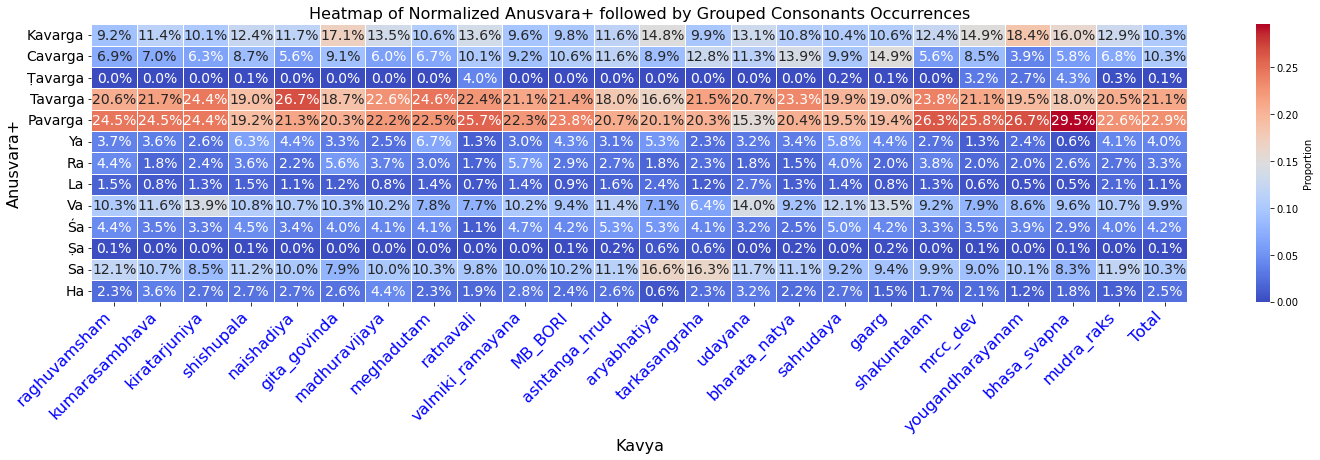

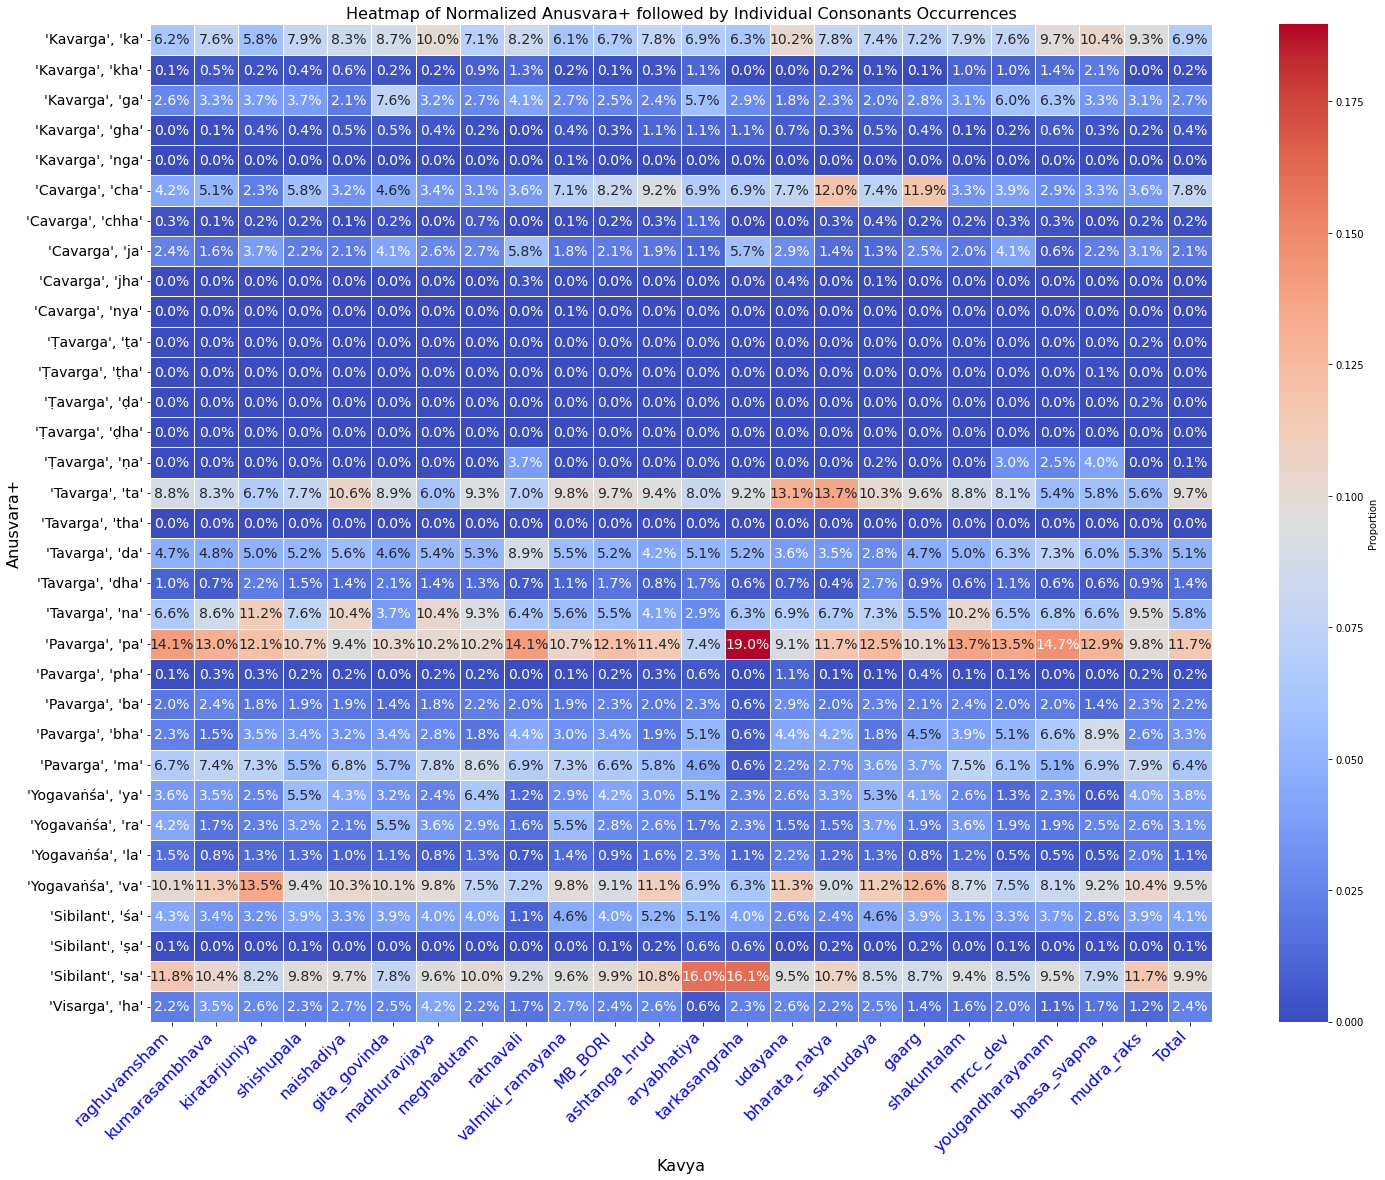

<Figure size 1008x576 with 0 Axes>

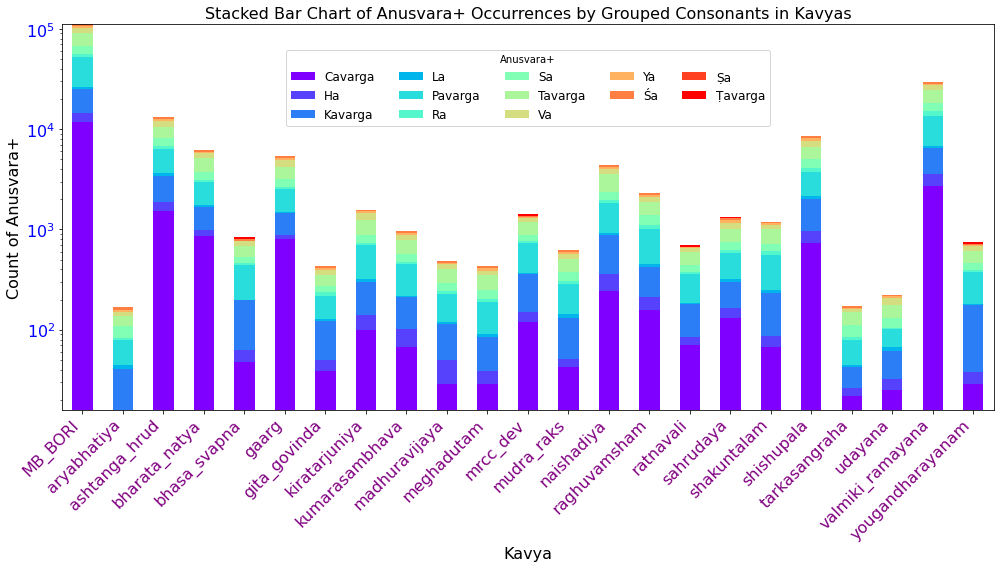

<Figure size 1008x576 with 0 Axes>

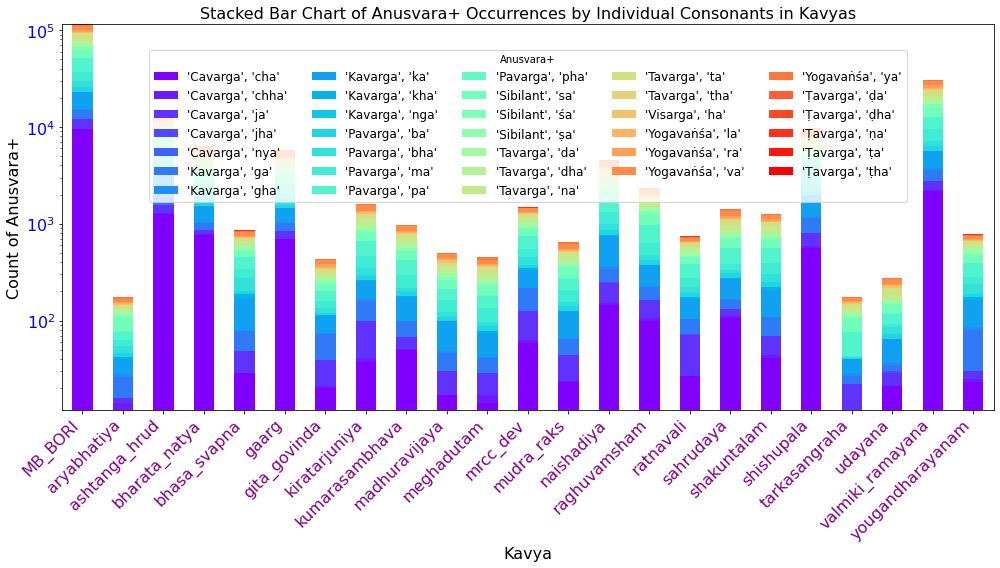

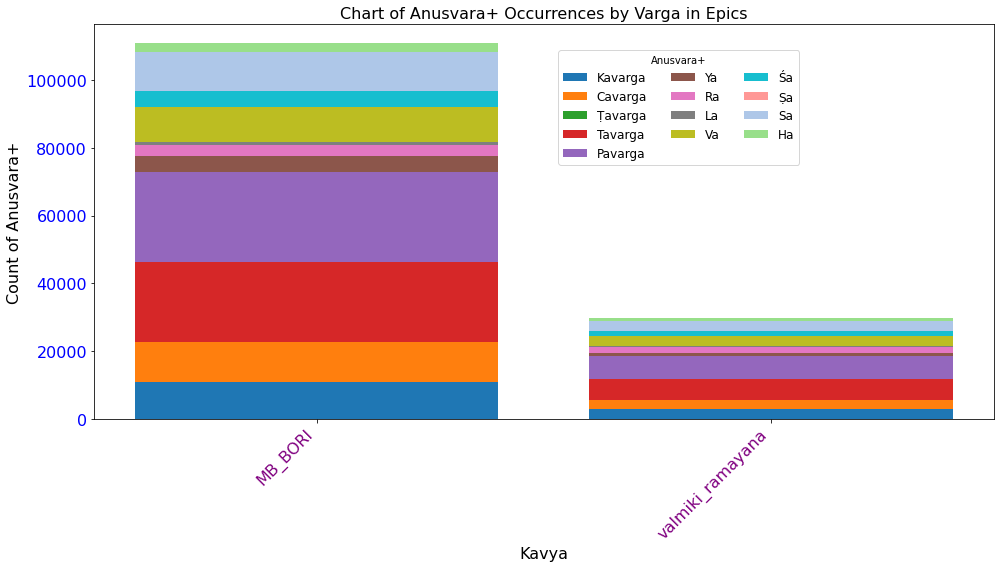

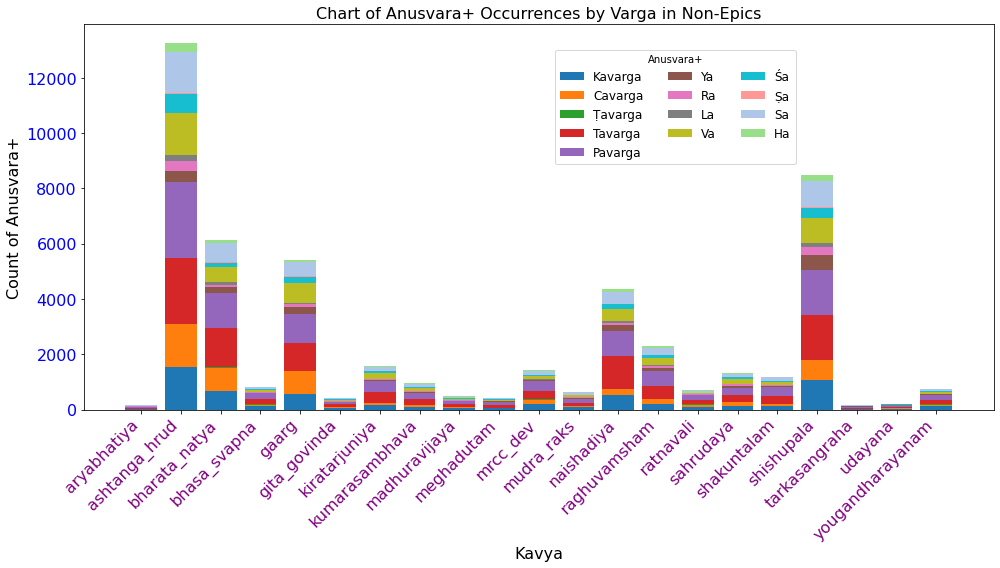

In [7]:
# function to create heatmap of normalized results using seaborn
import matplotlib.font_manager as fm
plt.rcParams['font.family'] = 'Noto Sans Devanagari'
plt.rcParams['font.family'] = 'DejaVu Sans'

def plot_heatmap(data_in, title , fmt='.1%'):
    data = data_in.copy()
    # retain ( not remove) the content in parenthesis in the index
    data.index = [re.sub(r'^.*\((.*?)\).*$', r'\1', str(idx)).strip() for idx in data.index]

    plt.figure(figsize=(20, len(data) * 0.5))
    sns.heatmap(data, annot=True, fmt=fmt, cmap='coolwarm', cbar_kws={'label': 'Proportion'}, annot_kws={"size": 14}, linewidths=.5, linecolor='white')
    plt.title(title, fontsize=16)
    plt.xlabel('Kavya', fontsize=16)
    plt.xticks(fontsize=16, rotation=45 , color='blue')  # Rotate x-ticks for better readability
    plt.tight_layout()
    plt.gca().set_xticklabels(plt.gca().get_xticklabels(), rotation=45, ha='right')
    plt.ylabel('Anusvara+', fontsize=16)
    plt.yticks(fontsize=14, rotation=0)  # Rotate y-ticks for better readability
    plt.show()

# Plot the heatmap for normalized results
plot_heatmap(ANUSVARA['Grouped Consonants']['normalized'], "Heatmap of Normalized Anusvara+ followed by Grouped Consonants Occurrences")
plot_heatmap(ANUSVARA['Individual Consonant']['normalized'], "Heatmap of Normalized Anusvara+ followed by Individual Consonants Occurrences")



import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

def plot_stacked_bar_chart(data, title):
    data = data.drop('Total', axis=0)
    data = data.drop('Total', axis=1)
    data.index = [re.sub(r'^.*\((.*?)\).*$', r'\1', str(idx)).strip() for idx in data.index]
    data.columns = [re.sub(r'^.*\((.*?)\).*$', r'\1', str(idx)).strip() for idx in data.columns]

    # Melt the DataFrame for seaborn
    melted_data = data.reset_index().melt(id_vars='index', var_name='Kavya', value_name='Count')
    melted_data.columns = ['Anusvara+', 'Kavya', 'Count']

    plt.figure(figsize=(14, 8))
    
    # Create a pivot table to group by 'Kavya'
    stacked_data = melted_data.pivot_table(index='Kavya', columns='Anusvara+', values='Count', aggfunc='sum')

    # Plot stacked bars
    stacked_data.plot(kind='bar', stacked=True, colormap='rainbow', figsize=(14, 8))

    plt.yscale('log')  # Log scale if needed
    plt.title(title, fontsize=16)
    plt.xlabel('Kavya', fontsize=16)
    plt.ylabel('Count of Anusvara+', fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=16, color='purple')
    plt.yticks(fontsize=16, color='blue')
    
    plt.legend(title='Anusvara+', fontsize=12, loc='upper center', bbox_to_anchor=(0.5, .95), ncol=5)
    plt.tight_layout()
    plt.show()

# Example call
plot_stacked_bar_chart(ANUSVARA['Grouped Consonants']['raw'], "Stacked Bar Chart of Anusvara+ Occurrences by Grouped Consonants in Kavyas")
plot_stacked_bar_chart(ANUSVARA['Individual Consonant']['raw'], "Stacked Bar Chart of Anusvara+ Occurrences by Individual Consonants in Kavyas")

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

# Define custom legend order and colors
custom_order = [
    "Kavarga", "Cavarga", "Ṭavarga", "Tavarga", "Pavarga",
    "Ya", "Ra", "La", "Va", "Śa", "Ṣa", "Sa", "Ha"
]

# Define custom colors
custom_palette = {
    "Kavarga": "#1f77b4", "Cavarga": "#ff7f0e", "Ṭavarga": "#2ca02c", "Tavarga": "#d62728",
    "Pavarga": "#9467bd", "Ya": "#8c564b", "Ra": "#e377c2", "La": "#7f7f7f",
    "Va": "#bcbd22", "Śa": "#17becf", "Ṣa": "#ff9896", "Sa": "#aec7e8", "Ha": "#98df8a"
}

def plot_stacked_bar_chart(data, title):
    # Clean up DataFrame
    if 'Total' in data.index: data = data.drop('Total', axis=0)
    if 'Total' in data.columns: data = data.drop('Total', axis=1)
    data.index = [re.sub(r'^.*\((.*?)\).*$', r'\1', idx).strip() for idx in data.index]
    data.columns = [re.sub(r'^.*\((.*?)\).*$', r'\1', idx).strip() for idx in data.columns]

    # Melt DataFrame into long format
    melted_data = data.reset_index().melt(id_vars='index', var_name='Kavya', value_name='Count')
    melted_data.columns = ['Anusvara+', 'Kavya', 'Count']

    # Pivot to prepare for stacking
    stacked_data = melted_data.pivot(index="Kavya", columns="Anusvara+", values="Count")

    # Plot stacked bars
    fig, ax = plt.subplots(figsize=(14, 8))
    bottom = np.zeros(len(stacked_data))

    for category in custom_order:
        if category in stacked_data.columns:
            ax.bar(stacked_data.index, stacked_data[category], label=category, color=custom_palette[category], bottom=bottom)
            bottom += stacked_data[category].fillna(0)  # Accumulate for stacking

    # Set log scale for y-axis
    # ax.set_yscale('log')

    plt.title(title, fontsize=16)
    plt.xlabel('Kavya', fontsize=16)
    plt.ylabel('Count of Anusvara+', fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=16, color='purple')
    plt.yticks(fontsize=16, color='blue')

    # Adjust legend order & make it horizontal
    ax.legend(title='Anusvara+', fontsize=12, loc='upper center', bbox_to_anchor=(0.65, .95), ncol=3)

    plt.tight_layout()
    plt.show()

# Example call
epics = ['valmiki_ramayana', 'MB_BORI']
non_epics = [col for col in results.columns if col not in epics]
results = ANUSVARA['Grouped Consonants']['raw']
plot_stacked_bar_chart(results[epics], "Chart of Anusvara+ Occurrences by Varga in Epics")
plot_stacked_bar_chart(results[non_epics], "Chart of Anusvara+ Occurrences by Varga in Non-Epics")


## Msvara section

In [12]:
from glob import glob
import os
import re

def extract_content_under_heading(filename: str, heading: str) -> str:
    """Extracts content under the specified heading from a Markdown file."""
    with open(filename, "r", encoding="utf-8") as file:
        content = file.readlines()

    pattern = re.compile(rf"^#+\s*{heading}\s*$", re.IGNORECASE)
    extracting = False
    extracted_content = []

    for line in content:
        if pattern.match(line.strip()):
            extracting = True
            continue
        elif extracting and re.match(r"^#+\s", line.strip()):
            extracting = not True
        if extracting:
            extracted_content.append(line)

    return "".join(extracted_content).strip()

def extract_padacheda_and_msvara( forcegen:bool = False) -> None:
    """
    Extract Padacheda and Patterns म् + स्वर content from Markdown files.
    """
    # Ensure the output directory exists
    os.makedirs("llm_post_processed", exist_ok=True)

    in_mds = sorted(glob("llm_pre_processed/*_llm_pp.md"))
    pcd_mds = [ f"{re.sub(r'_llm_pp.md$', '', md)}" for md in in_mds]
    pcd_mds = [ f"{re.sub(r'llm_pre_processed/', 'llm_post_processed/zpadacheda_', md)}.md" for md in pcd_mds]

    # Extract content under "Padacheda:" heading from each input Markdown file
    print(f"Processing {len(in_mds)} files for Padacheda content extraction...")
    for in_md, out_md in zip(in_mds, pcd_mds):
        # skip if the output file already exists
        if not forcegen and out_md in glob("llm_post_processed/*.md"):
            print(f"\t*** Skipping {out_md} as it already exists.")
            continue

        print(f"\tExtracting content from {in_md} to {out_md}")
        content = extract_content_under_heading(in_md, "Padacheda:")
        with open(out_md, "w", encoding="utf-8") as file:
            file.write(content)

    ### Patterns म् + स्वर:
    msvara_mds = [ f"{re.sub(r'_llm_pp.md$', '', md)}" for md in in_mds]
    msvara_mds = [ f"{re.sub(r'llm_pre_processed/', 'llm_post_processed/zmsvara_', md)}.md" for md in msvara_mds]
    print(f"\nProcessing {len(in_mds)} files for Patterns म् + स्वर content extraction...")
    for in_md, out_md in zip(in_mds, msvara_mds):
        # skip if the output file already exists
        if not forcegen and out_md in glob("llm_post_processed/*.md"):
            print(f"\t*** Skipping {out_md} as it already exists.")
            continue

        print(f"\tExtracting content from {in_md} to {out_md}")
        content = extract_content_under_heading(in_md, "Patterns म् . स्वर:")
        content_lines = content.splitlines()
        # first two lines are the header
        con = content_lines[:2]
        # rest is the content
        rest = content_lines[2:]
        # filter lines containing \d+\s*\|\s*$
        content = [line for line in rest if re.search(r"[1-9]\d*\s*\|\s*$", line)]
        # reduce mutiple spaces to single space
        content = [re.sub(r'\s+', ' ', line.strip()) for line in content]
        # filter lines with **
        content = [line for line in content if not re.search(r"\*\*", line)]
        # join the lines back
        content = "\n".join(content)

        with open(out_md, "w", encoding="utf-8") as file:
            file.write(content)

    print("\nExtraction completed. Check the 'llm_post_processed' directory for output files.")

extract_padacheda_and_msvara(forcegen=False)


Processing 21 files for Padacheda content extraction...
	*** Skipping llm_post_processed/zpadacheda_Sahrudayaloka_of_Dhvanyaloka.md as it already exists.
	*** Skipping llm_post_processed/zpadacheda_Shudraka_Mrcchakatikam_devanagari.md as it already exists.
	*** Skipping llm_post_processed/zpadacheda_aryabhatiya.md as it already exists.
	*** Skipping llm_post_processed/zpadacheda_ashtanga_hrudaya.md as it already exists.
	*** Skipping llm_post_processed/zpadacheda_bharata_natya_shastra.md as it already exists.
	*** Skipping llm_post_processed/zpadacheda_bharavi_kiratarjuniya.md as it already exists.
	*** Skipping llm_post_processed/zpadacheda_bhasa_pratijna_yougandharayanam.md as it already exists.
	*** Skipping llm_post_processed/zpadacheda_bhasa_svapnavasadatta.md as it already exists.
	*** Skipping llm_post_processed/zpadacheda_gangadevi_madhuravijaya.md as it already exists.
	*** Skipping llm_post_processed/zpadacheda_jayadeva_gita_govinda.md as it already exists.
	*** Skipping llm_

In [18]:
def make_msvara_df () -> pd.DataFrame :
    """
    Read the zmsvara files matching patterns and create a DataFrame with Kavya name as the first column.
    The kavya name is normalized pattern - remove special characters and spaces.
    the zmsvara files are expected to have the following format ( verse | svara | instance | count ):

    |1.2|अ| परिवारितम् अनध्याये | 1|
    |1.19|इ| सुरेश्वरम् इतिहासो | 1|
    |1.22|अ| सत्तम अशक्ता | 1|
    |1.26|अ| जटिलम् अम्बष्टकौ, तण्डुम् अग्निशिखम् | 2 |

    The output DataFrame will be created by concatenating all individual DataFrames from the zmsvara files.
    The output DataFrame will have the following columns:
    - kavya
    - verse
    - svara
    - instance
    - count

    """

    zmsvara_pat_mds = {}
    zmsvara_mds = glob("llm_post_processed/zmsvara_*.md")
    for f in zmsvara_mds:
        for p in file_patterns:
            p = re.sub(r'\.txt$', '', p)
            zmsvara_pat_mds[p] = zmsvara_pat_mds.get(p, []) 
            if re.search(p, f, re.IGNORECASE):
                zmsvara_pat_mds[p] = zmsvara_pat_mds.get(p, []) + [f]
    # # Display the mapping of file patterns to zmsvara files
    # for p, files in zmsvara_pat_mds.items():
    #     print(f"{p}: {', '.join(files)}")

    zdfs = []
    # Read each zmsvara file, normalize the Kavya name, and create a DataFrame
    for pat, zfns in zmsvara_pat_mds.items():
        if not zfns: 
            print(f"No files found for pattern {pat}")
            continue

        zfn = zfns[0]
        # print(f"\nProcessing {zfn}")
        norm_fm = re.sub(r'^zmsvara_', '', zfn)
        kavya = re.sub(r'.md$', '', norm_fm)
        zdf = pd.read_csv(zfn, sep='|', header=None, names=['x0', 'verse', 'svara', 'instance', 'count', 'x1']).drop(columns=['x0','x1'])

        norm_pat = pat.replace('.txt', '').strip()
        norm_pat = re.sub(r'[^a-zA-Z0-9_\S]', '', norm_pat)  # Normalize pattern to a valid column name
        norm_pat = re.sub(r'^\W*', '', norm_pat).strip()  # Remove leading non-word characters
        norm_pat = re.sub(r'\W*$', '', norm_pat).strip()  # Remove trailing non-word characters
        norm_pat = re.sub(r'\W\W*', '_', norm_pat).strip()  # Replace multiple non-word characters with a single underscore
        # Insert the Kavya name as the first column

        zdf.insert(0, 'kavya', norm_pat)
        # zdf.insert(0, 'kavya', kavya)
        print(f"Read {len(zdf):-4d} rows from {zfn}")
        zdf['kavya'] = zdf['kavya'].str.strip()

        zdf['svara'] = zdf['svara'].apply(lambda x: re.sub(r'म्\+', ' ', x.strip()) if isinstance(x, str) else x)

        # zdf['count'] = zdf['count'].astype(int)
        # zdf['verse'] = zdf['verse'].str.strip()
        # zdf['svara'] = zdf['svara'].str.strip()
        # zdf['instance'] = zdf['instance'].str.strip()

        # prepend a column with the Kavya name
    
        zdfs.append(zdf)
    # Concatenate all DataFrames into a single DataFrame
    zdf = pd.concat(zdfs, ignore_index=True)
    zdf.to_csv("llm_post_processed/zmsvara_combined.csv", index=False, encoding='utf-8-sig')
    return zdf

zdf = make_msvara_df()
# Display the first few rows of the DataFrame
print(f"\nTotal rows in the DataFrame: {len(zdf)}")
display(zdf.sample(10).style)





Read 1359 rows from llm_post_processed/zmsvara_kalidasa_raghuvamsham.md
Read  576 rows from llm_post_processed/zmsvara_kalidasa_kumarasambhava.md
Read 1044 rows from llm_post_processed/zmsvara_bharavi_kiratarjuniya.md
Read 1863 rows from llm_post_processed/zmsvara_magha_shishupala_vadha.md
Read 2672 rows from llm_post_processed/zmsvara_shriharsha_naishadiya_charitam.md
Read  269 rows from llm_post_processed/zmsvara_jayadeva_gita_govinda.md
Read   58 rows from llm_post_processed/zmsvara_gangadevi_madhuravijaya.md
Read  144 rows from llm_post_processed/zmsvara_kalidasa_meghadutam.md
Read   81 rows from llm_post_processed/zmsvara_shriharsha_ratnavali.md
No files found for pattern valmiki-ramayana
No files found for pattern ^.*MB.*BORI.*$
Read   17 rows from llm_post_processed/zmsvara_ashtanga_hrudaya.md
Read   37 rows from llm_post_processed/zmsvara_aryabhatiya.md
Read   24 rows from llm_post_processed/zmsvara_tarkasangraha_म_लम_.md
Read   25 rows from llm_post_processed/zmsvara_udayana_n

,kavya,verse,svara,instance,count
7493,naishadiya,22.139,अ,मुखम् अयम्,1
9060,bharata_natya,15.131,आ,चतुर्थम् आद्यम्,1
9928,gaarg,1360,अ,"परम् अश्रूयते, एवम् अगस्त्यस्य",2
2809,kiratarjuniya,15.320000,आ,ईशानम् आश्वास,1
3941,shishupala,16,अ,मदरुचिम् अरुणेन,1
5216,naishadiya,4.39,इ,"मृणालिकामयम् इयम्, भुजगास्त्रम् इव",2
8118,aryabhatiya,4.370000,अ,जलम् अर्कः,1
6485,naishadiya,14.74,अ,संतापम् अन्तः,1
7492,naishadiya,22.138,उ,कुरङ्गम् उदरे,1
2376,kiratarjuniya,9.370000,ए,यातम् एव,1


In [20]:
def cross_tabulate_msvara(zdf: pd.DataFrame) -> tuple:
    """
    Cross-tabulate the msvara DataFrame to get counts of svara occurrences by kavya.
    
    Args:
        zdf: DataFrame containing msvara data with columns ['kavya', 'verse', 'svara', 'instance', 'count']
    """
    zdf.svara = zdf.svara.str.strip()
    zdf.kavya = zdf.kavya.str.strip()
    zdf.verse = zdf.verse.str.strip()
    zdf['count'] = zdf['count'].astype(int)

    msvara_df = zdf.pivot_table(
        index='kavya', columns='svara', values='count', aggfunc='sum'
    ).fillna(0).astype(int).drop(columns=['Total' , 'अं' ,'व' ,'स्']).T


    msvara_normalized_df = msvara_df.copy()
    for col in msvara_normalized_df.columns: 
        msvara_normalized_df[col] = msvara_normalized_df[col] / msvara_normalized_df[col].sum()

    return msvara_df, msvara_normalized_df


# gist.columns = [ re.sub("_", "<br>", x) for x in gist.columns]
# gist.columns = [ "<br>".join(x.split("_")[1:]) for x in gist.columns]



In [97]:
msvara_df, msvara_normalized_df = cross_tabulate_msvara(zdf)
# Display the results
display(
    # HTML(f"<h2>Normalized म्+स्वरः Occurrences </h2>"),
    msvara_normalized_df.T.style.format("{:.1%}").background_gradient(cmap='coolwarm').set_caption("<h3>Normalized Counts of म्+स्वरः Occurrences</h3>"),
    HTML("<hr>"),
    # HTML(f"<h2>Raw Counts of म्+स्वरः Occurrences</h2>"),
    msvara_df.T.style.background_gradient(cmap='Reds').format("{:,}").set_caption("<h3>Raw Counts of म्+स्वरः Occurrences</h3>")
)

svara,अ,आ,इ,ई,उ,ऊ,ऋ,ए,ऐ,ओ,औ
kavya,,,,,,,,,,,
aryabhatiya,62.2%,2.2%,6.7%,0.0%,15.6%,0.0%,11.1%,2.2%,0.0%,0.0%,0.0%
ashtanga_hrud,58.8%,17.6%,0.0%,0.0%,11.8%,5.9%,5.9%,0.0%,0.0%,0.0%,0.0%
bharata_natya,37.5%,12.4%,11.4%,0.8%,13.1%,1.0%,0.6%,22.6%,0.0%,0.2%,0.3%
bhasa_svapna,38.0%,15.7%,23.1%,0.9%,10.2%,0.0%,0.0%,12.0%,0.0%,0.0%,0.0%
gaarg,30.1%,24.1%,4.8%,0.0%,22.9%,2.4%,3.6%,10.8%,1.2%,0.0%,0.0%
gita_govinda,57.1%,4.6%,21.8%,0.3%,12.0%,0.6%,0.0%,3.7%,0.0%,0.0%,0.0%
kiratarjuniya,43.3%,14.0%,18.8%,1.8%,15.1%,0.7%,0.7%,4.4%,0.2%,0.7%,0.3%
kumarasambhava,44.3%,20.0%,13.3%,1.5%,11.3%,0.5%,1.1%,7.2%,0.6%,0.2%,0.0%
madhuravijaya,38.5%,20.0%,18.5%,1.5%,12.3%,0.0%,0.0%,6.2%,3.1%,0.0%,0.0%


svara,अ,आ,इ,ई,उ,ऊ,ऋ,ए,ऐ,ओ,औ
kavya,,,,,,,,,,,
aryabhatiya,28,1,3,0,7,0,5,1,0,0,0
ashtanga_hrud,10,3,0,0,2,1,1,0,0,0,0
bharata_natya,646,214,196,14,226,18,11,389,0,4,5
bhasa_svapna,41,17,25,1,11,0,0,13,0,0,0
gaarg,25,20,4,0,19,2,3,9,1,0,0
gita_govinda,186,15,71,1,39,2,0,12,0,0,0
kiratarjuniya,520,168,226,21,181,8,8,53,3,8,4
kumarasambhava,290,131,87,10,74,3,7,47,4,1,0
madhuravijaya,25,13,12,1,8,0,0,4,2,0,0


In [26]:
def make_msound_df() -> tuple:
    """
    Create a DataFrame with sounds from the msvara_df and ANUSVARA data.
    This function maps svara to sound using the char_groups dictionary.
    The index of msvara and ANUSVARA will be the sounds, and the columns will be the kavya names.

    Returns:
        DataFrame with sounds as index and kavya as columns.
    """

    msvara_cols = msvara_df.columns.tolist()
    anusvara_ind_df = ANUSVARA['Individual Consonant']['raw'][msvara_cols]
    anusvara_grp_df = ANUSVARA['Grouped Consonants']['raw'][msvara_cols]

    # stack msvara_df and anusvara_ind_df
    _a = anusvara_ind_df.drop(index=['Total']).stack().reset_index()
    _a.columns = ['svara', 'kavya', 'count']
    _p = _a
    # _p = _a[_a.svara.apply(lambda x: 'Pa' in str(x))]
    # _pmap ={
    #     ('Pavarga', 'pa'): 'प्',
    #     ('Pavarga', 'pha'): 'फ्',
    #     ('Pavarga', 'ba'): 'ब्',
    #     ('Pavarga', 'bha'): 'भ्',
    #     ('Pavarga', 'ma'): 'म्'
    # }
    # # Replace the 'svara' column values with the mapped values
    # for k, v in _pmap.items():
    #     _p.loc[_p.svara == k, 'svara'] = v


    _m = msvara_df.stack().reset_index()
    _m.columns = ['svara', 'kavya', 'count']
    # _m1 = _m[_m.svara.apply(lambda x: 'म्+' not in str(x))]
    # _m1 = _m1[_m1.svara.apply(lambda x: 'व' not in str(x))]
    # display( _m.head().style , _a.head().style)

    # Append _p to _m row wise
    mboth_df = pd.concat([_m, _p], ignore_index=True)
    mboth_df = mboth_df.assign(
        sound=lambda x: x.svara.apply(lambda z: char_groups.get(z, [z])[0]),  # Map svara to its group
        kavya=lambda x: x['kavya'].str.strip()  # Ensure kavya names are stripped of whitespace
    )

    # mboth_df.columns = ['svara', 'kavya', 'count']
    # mboth_df = mboth_df.pivot_table(index='svara', columns='kavya', values='count', fill_value=0)
    mboth_df = mboth_df.pivot_table(index='sound', columns='kavya', values='count', fill_value=0)

    mboth_normalized_df = mboth_df.copy()
    # mboth_normalized_df = mboth_normalized_df.div(mboth_normalized_df.sum(axis=1), axis=0)
    for col in mboth_normalized_df.columns: 
        mboth_normalized_df[col] = mboth_normalized_df[col] / mboth_normalized_df[col].sum()
    # Display the results

    mboth_normalized_df.T.to_csv("msound_normalized.csv", encoding='utf-8-sig')
    mboth_df.T.to_csv("msound_raw.csv", encoding='utf-8-sig')
    print("Saved msound_normalized.csv and msound_raw.csv")



    return mboth_df, mboth_normalized_df

    # display(
    #     # HTML(f"<h2>Normalized म्+स्वरः Occurrences </h2>"),
    #     msvara_normalized_df.style.format("{:.1%}").background_gradient(cmap='coolwarm').set_caption("<h3>Normalized Counts of म्+स्वरः Occurrences</h3>"),
    #     anusvara_ind_normalized_df.style.format("{:.1%}").background_gradient(cmap='coolwarm').set_caption("<h3>Normalized Counts of म्+स्वरः Occurrences by Individual Consonants</h3>"),
    #     anusvara_grp_normalized_df.style.format("{:.1%}").background_gradient(cmap='coolwarm').set_caption("<h3>Normalized Counts of म्+स्वरः Occurrences by Grouped Consonants</h3>"),
    #     HTML("<hr>"),
    #     # HTML(f"<h2>Raw Counts of म्+स्वरः Occurrences</h2>"),
    #     msvara_df.style.background_gradient(cmap='Reds').format("{:,}").set_caption("<h3>Raw Counts of म्+स्वरः Occurrences</h3>"),
    #     anusvara_ind_df.style.background_gradient(cmap='Reds').format("{:,}").set_caption("<h3>Raw Counts of म्+स्वरः Occurrences by Individual Consonants</h3>"),
    #     anusvara_grp_df.style.background_gradient(cmap='Reds').format("{:,}").set_caption("<h3>Raw Counts of म्+स्वरः Occurrences by Grouped Consonants</h3>")

    # )

msound_df, msound_normalized_df = make_msound_df()

display(
    # HTML(f"<h2>Normalized म्+स्वरः Occurrences by Individual Consonants</h2>"),
    msound_normalized_df.T.style.format("{:.1%}").background_gradient(cmap='coolwarm').set_caption("<h3>Normalized Counts of म्+स्वरः Occurrences by Individual Consonants</h3>"),
    HTML("<hr>"),
    # HTML(f"<h2>Raw Counts of म्+स्वरः Occurrences by Individual Consonants</h2>"),
    msound_df.T.style.background_gradient(cmap='Reds').format("{:,}").set_caption("<h3>Raw Counts of म्+स्वरः Occurrences by Individual Consonants</h3>")
)

Saved msound_normalized.csv and msound_raw.csv


sound,अ,आ,इ,ई,उ,ऊ,ऋ,ए,ऐ,ओ,औ,क्,ख्,ग्,घ्,ङ्,च्,छ्,ज्,झ्,ञ्,ट्,ठ्,ड्,ढ्,ण्,त्,थ्,द्,ध्,न्,प्,फ्,ब्,भ्,म्,य्,र्,ल्,व्,श्,ष्,स्,ह्
kavya,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
aryabhatiya,12.7%,0.5%,1.4%,0.0%,3.2%,0.0%,2.3%,0.5%,0.0%,0.0%,0.0%,5.5%,0.9%,4.5%,0.9%,0.0%,5.5%,0.9%,0.9%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,6.4%,0.0%,4.1%,1.4%,2.3%,5.9%,0.5%,1.8%,4.1%,3.6%,4.1%,1.4%,1.8%,5.5%,4.1%,0.5%,12.7%,0.5%
ashtanga_hrud,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,7.8%,0.3%,2.4%,1.1%,0.0%,9.2%,0.3%,1.9%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,9.4%,0.0%,4.2%,0.8%,4.1%,11.4%,0.3%,2.0%,1.9%,5.8%,3.0%,2.6%,1.5%,11.1%,5.2%,0.2%,10.8%,2.6%
bharata_natya,8.0%,2.7%,2.4%,0.2%,2.8%,0.2%,0.1%,4.8%,0.0%,0.0%,0.1%,6.2%,0.1%,1.8%,0.2%,0.0%,9.4%,0.2%,1.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,10.8%,0.0%,2.7%,0.3%,5.3%,9.2%,0.1%,1.6%,3.3%,2.1%,2.6%,1.2%,1.0%,7.0%,1.9%,0.2%,8.4%,1.7%
bhasa_svapna,4.2%,1.7%,2.6%,0.1%,1.1%,0.0%,0.0%,1.3%,0.0%,0.0%,0.0%,9.2%,1.8%,3.0%,0.3%,0.0%,3.0%,0.0%,1.9%,0.0%,0.0%,0.0%,0.1%,0.0%,0.0%,3.6%,5.1%,0.0%,5.3%,0.5%,5.8%,11.5%,0.0%,1.2%,7.9%,6.1%,0.5%,2.3%,0.4%,8.2%,2.5%,0.1%,7.1%,1.5%
gaarg,0.4%,0.3%,0.1%,0.0%,0.3%,0.0%,0.1%,0.2%,0.0%,0.0%,0.0%,7.1%,0.1%,2.7%,0.4%,0.0%,11.7%,0.2%,2.5%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,9.4%,0.0%,4.6%,0.9%,5.5%,9.9%,0.4%,2.1%,4.4%,3.7%,4.0%,1.8%,0.7%,12.4%,3.9%,0.2%,8.6%,1.4%
gita_govinda,24.4%,2.0%,9.3%,0.1%,5.1%,0.3%,0.0%,1.6%,0.0%,0.0%,0.0%,5.0%,0.1%,4.3%,0.3%,0.0%,2.6%,0.1%,2.4%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,5.1%,0.0%,2.6%,1.2%,2.1%,5.9%,0.0%,0.8%,2.0%,3.3%,1.8%,3.1%,0.7%,5.8%,2.2%,0.0%,4.5%,1.4%
kiratarjuniya,18.5%,6.0%,8.0%,0.7%,6.4%,0.3%,0.3%,1.9%,0.1%,0.3%,0.1%,3.3%,0.1%,2.1%,0.2%,0.0%,1.3%,0.1%,2.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,3.8%,0.0%,2.8%,1.2%,6.4%,7.0%,0.2%,1.0%,2.0%,4.2%,1.5%,1.3%,0.7%,7.7%,1.8%,0.0%,4.7%,1.5%
kumarasambhava,17.7%,8.0%,5.3%,0.6%,4.5%,0.2%,0.4%,2.9%,0.2%,0.1%,0.0%,4.6%,0.3%,2.0%,0.1%,0.0%,3.1%,0.1%,1.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,5.0%,0.0%,2.9%,0.4%,5.1%,7.8%,0.2%,1.5%,0.9%,4.5%,2.1%,1.0%,0.5%,6.8%,2.0%,0.0%,6.2%,2.1%
madhuravijaya,4.4%,2.3%,2.1%,0.2%,1.4%,0.0%,0.0%,0.7%,0.4%,0.0%,0.0%,8.8%,0.2%,2.8%,0.4%,0.0%,3.0%,0.0%,2.3%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,5.3%,0.0%,4.8%,1.2%,9.2%,9.0%,0.2%,1.6%,2.5%,6.9%,2.1%,3.2%,0.7%,8.7%,3.5%,0.0%,8.5%,3.7%


sound,अ,आ,इ,ई,उ,ऊ,ऋ,ए,ऐ,ओ,औ,क्,ख्,ग्,घ्,ङ्,च्,छ्,ज्,झ्,ञ्,ट्,ठ्,ड्,ढ्,ण्,त्,थ्,द्,ध्,न्,प्,फ्,ब्,भ्,म्,य्,र्,ल्,व्,श्,ष्,स्,ह्
kavya,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
aryabhatiya,28.0,1.0,3.0,0.0,7.0,0.0,5.0,1.0,0.0,0.0,0.0,12.0,2.0,10.0,2.0,0.0,12.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0,9.0,3.0,5.0,13.0,1.0,4.0,9.0,8.0,9.0,3.0,4.0,12.0,9.0,1.0,28.0,1.0
ashtanga_hrud,10.0,3.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,"1,062.0",45.0,332.0,152.0,0.0,"1,257.0",44.0,259.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"1,291.0",0.0,572.0,110.0,566.0,"1,556.0",47.0,273.0,258.0,797.0,410.0,357.0,212.0,"1,513.0",705.0,27.0,"1,474.0",351.0
bharata_natya,646.0,214.0,196.0,14.0,226.0,18.0,11.0,389.0,0.0,4.0,5.0,497.0,12.0,148.0,17.0,0.0,760.0,20.0,86.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,867.0,0.0,220.0,27.0,427.0,742.0,7.0,129.0,268.0,172.0,210.0,94.0,78.0,568.0,151.0,14.0,680.0,137.0
bhasa_svapna,41.0,17.0,25.0,1.0,11.0,0.0,0.0,13.0,0.0,0.0,0.0,90.0,18.0,29.0,3.0,0.0,29.0,0.0,19.0,0.0,0.0,0.0,1.0,0.0,0.0,35.0,50.0,0.0,52.0,5.0,57.0,112.0,0.0,12.0,77.0,60.0,5.0,22.0,4.0,80.0,24.0,1.0,69.0,15.0
gaarg,25.0,20.0,4.0,0.0,19.0,2.0,3.0,9.0,1.0,0.0,0.0,416.0,3.0,162.0,22.0,0.0,690.0,10.0,147.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,557.0,0.0,271.0,54.0,322.0,586.0,22.0,123.0,262.0,216.0,237.0,108.0,44.0,733.0,229.0,10.0,507.0,83.0
gita_govinda,186.0,15.0,71.0,1.0,39.0,2.0,0.0,12.0,0.0,0.0,0.0,38.0,1.0,33.0,2.0,0.0,20.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.0,0.0,20.0,9.0,16.0,45.0,0.0,6.0,15.0,25.0,14.0,24.0,5.0,44.0,17.0,0.0,34.0,11.0
kiratarjuniya,520.0,168.0,226.0,21.0,181.0,8.0,8.0,53.0,3.0,8.0,4.0,94.0,4.0,59.0,6.0,0.0,37.0,4.0,59.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,108.0,0.0,80.0,35.0,180.0,196.0,5.0,29.0,57.0,118.0,41.0,37.0,21.0,218.0,51.0,0.0,133.0,42.0
kumarasambhava,290.0,131.0,87.0,10.0,74.0,3.0,7.0,47.0,4.0,1.0,0.0,75.0,5.0,32.0,1.0,0.0,50.0,1.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,81.0,0.0,47.0,7.0,84.0,128.0,3.0,24.0,15.0,73.0,34.0,17.0,8.0,111.0,33.0,0.0,102.0,34.0
madhuravijaya,25.0,13.0,12.0,1.0,8.0,0.0,0.0,4.0,2.0,0.0,0.0,50.0,1.0,16.0,2.0,0.0,17.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,27.0,7.0,52.0,51.0,1.0,9.0,14.0,39.0,12.0,18.0,4.0,49.0,20.0,0.0,48.0,21.0


In [96]:

display(
    HTML("<h3>Normalized Counts of म्+स्वरः Occurrences by Individual Consonants</h3>"),
    msound_normalized_df.applymap(lambda x: int(100*x) if pd.notnull(x) else 0).style
        # .format("{:.1%}")
        .background_gradient(cmap='Reds')
        .set_table_styles([
            {'selector': 'th.col_heading', 
             'props': 'transform: rotate(-90deg) translate(-50px, -35px); height: 90px; vertical-align: bottom; white-space: wrap; font-size: 14px;'},
            {'selector': 'td', 
             'props': 'white-space: nowrap; padding: 0px 2px; font-size: 12px; color: ivory;'},
            {'selector': 'th.row_heading',
             'props': 'white-space: nowrap; padding: 0px 2px; font-size: 12px;'},
            {'selector': 'table', 
             'props': 'table-layout: fixed; width: auto;'},
            {'selector': 'thead th', 
             'props': 'min-width: 14px; max-width: 20px;'}
        ]),
    HTML("<hr>"),
    HTML("<h3>Raw Counts of म्+स्वरः Occurrences by Individual Consonants</h3>"),
    msound_df.applymap(lambda x: int(x) if pd.notnull(x) else 0).style
        .background_gradient(cmap='Reds')
        .format("{:,}")
        .set_table_styles([
            {'selector': 'th.col_heading', 
             'props': 'transform: rotate(-90deg) translate(-50px, -35px); height: 90px; vertical-align: bottom; white-space: wrap; font-size: 14px;'},
            {'selector': 'td', 
             'props': 'white-space: nowrap; padding: 0px 2px; font-size: 12px; color: ivory;'},
            {'selector': 'th.row_heading',
             'props': 'white-space: nowrap; padding: 0px 2px; font-size: 13px;'},
            {'selector': 'table', 
             'props': 'table-layout: fixed; width: auto;'},
            {'selector': 'thead th', 
             'props': 'min-width: 14px; max-width: 20px;'}
        ])
)

/var/folders/yw/khs2fgqs5d39_5lgfvh8mqlh0000gn/T/ipykernel_39937/4188155513.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  msound_normalized_df.applymap(lambda x: int(100*x) if pd.notnull(x) else 0).style
/var/folders/yw/khs2fgqs5d39_5lgfvh8mqlh0000gn/T/ipykernel_39937/4188155513.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  msound_df.applymap(lambda x: int(x) if pd.notnull(x) else 0).style


kavya,aryabhatiya,ashtanga_hrud,bharata_natya,bhasa_svapna,gaarg,gita_govinda,kiratarjuniya,kumarasambhava,madhuravijaya,meghadutam,mrcc_dev,mudra_raks,naishadiya,raghuvamsham,ratnavali,sahrudaya,shakuntalam,shishupala,tarkasangraha,udayana,yougandharayanam
sound,,,,,,,,,,,,,,,,,,,,,
अ,12,0,8,4,0,24,18,17,4,14,4,12,21,18,4,4,10,10,7,6,4
आ,0,0,2,1,0,1,5,8,2,4,1,2,5,7,1,0,4,2,1,0,1
इ,1,0,2,2,0,9,8,5,2,2,2,7,4,4,1,1,3,2,1,1,2
ई,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
उ,3,0,2,1,0,5,6,4,1,2,1,2,3,3,1,0,2,2,0,2,1
ऊ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ऋ,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ए,0,0,4,1,0,1,1,2,0,1,1,2,3,2,1,1,1,1,1,0,0
ऐ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


kavya,aryabhatiya,ashtanga_hrud,bharata_natya,bhasa_svapna,gaarg,gita_govinda,kiratarjuniya,kumarasambhava,madhuravijaya,meghadutam,mrcc_dev,mudra_raks,naishadiya,raghuvamsham,ratnavali,sahrudaya,shakuntalam,shishupala,tarkasangraha,udayana,yougandharayanam
sound,,,,,,,,,,,,,,,,,,,,,
अ,28,10,646,41,25,186,520,290,25,91,68,113,"1,658",709,41,70,165,"1,228",15,21,36
आ,1,3,214,17,20,15,168,131,13,27,18,19,431,305,13,14,68,275,3,2,14
इ,3,0,196,25,4,71,226,87,12,15,37,68,350,190,16,22,50,289,4,4,21
ई,0,0,14,1,0,1,21,10,1,1,1,3,55,24,0,1,2,32,1,1,0
उ,7,2,226,11,19,39,181,74,8,18,24,23,298,152,17,11,33,325,1,8,14
ऊ,0,1,18,0,2,2,8,3,0,0,0,1,27,7,0,1,0,18,0,1,0
ऋ,5,1,11,0,3,0,8,7,0,0,0,2,8,31,0,0,1,7,0,0,1
ए,1,0,389,13,9,12,53,47,4,11,21,21,259,97,10,26,26,142,4,2,6
ऐ,0,0,0,0,1,0,3,4,2,1,0,1,21,7,2,0,0,7,0,0,1
